# Modelado Estocástico

## Forecast

Para la implementación de las predicciones vamos a utilizar los datos del trigo presentados previamente.

In [15]:
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)

In [ ]:
df = pd.read_excel('wheat.xlsx')
df.head()

,yearmm,wheat_srw,wheat_hrw
0,1980M01,169.71,175.63
1,1980M02,170.49,172.70
2,1980M03,162.40,163.51
3,1980M04,155.80,156.53
4,1980M05,156.20,161.30


In [ ]:
df.tail()

,yearmm,wheat_srw,wheat_hrw
496,2021M05,270.984566,297.25
497,2021M06,263.477834,285.55
498,2021M07,254.670377,294.27
499,2021M08,276.183796,324.52
500,2021M09,263.599089,337.55


Utilizamos la fecha como índice y calculamos los retornos logarítmicos en la columna `dlws`

In [ ]:
inicio = pd.to_datetime(df['yearmm'].iloc[0], format='%YM%m').strftime('%Y-%m')
df['date'] = pd.period_range(start=inicio, periods=len(df), freq="M")
df = df.set_index("date")

df["wheat_srw"] = pd.to_numeric(df["wheat_srw"], errors="coerce")
df["dlws"] = np.log(df["wheat_srw"]).diff()
df = df[['wheat_srw','wheat_hrw','dlws']]
df


,wheat_srw,wheat_hrw,dlws
date,,,
1980-01,169.710000,175.63,NaN
1980-02,170.490000,172.70,0.004586
1980-03,162.400000,163.51,-0.048614
1980-04,155.800000,156.53,-0.041489
1980-05,156.200000,161.30,0.002564
...,...,...,...
2021-05,270.984566,297.25,-0.037642
2021-06,263.477834,285.55,-0.028093
2021-07,254.670377,294.27,-0.033999


### Estimación de un AR(1).

Vamos a estimar un AR(1) porque es de los modelos más simples. De hecho, ajustar los retornos logarítmicos del trigo por un AR(1) es un ajuste pobre, malo y equivocado. Pero el objetivo de este Notebook es ejemplificar las implementaciones y comprender qué tipo de pronóstico obtenemos y no un análisis riguroso de los datos de la muestra.

Un AR(1) permite hacer algunas cuentas que ayudan a entender cómo formamos pronósticos. El ejemplo desarrollado para un AR(1) se puede generalizar y aplicar a cualquier serie de tiempo ARIMA.

In [ ]:
y = df["dlws"].dropna()
ar1_model = ARIMA(y, order=(1,0,0))
ar1_res = ar1_model.fit()
print(ar1_res.summary())


                               SARIMAX Results                                
Dep. Variable:                   dlws   No. Observations:                  500
Model:                 ARIMA(1, 0, 0)   Log Likelihood                 668.793
Date:                Sat, 15 Aug 2026   AIC                          -1331.586
Time:                        16:15:09   BIC                          -1318.942
Sample:                    02-29-1980   HQIC                         -1326.625
                         - 09-30-2021                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0009      0.003      0.252      0.801      -0.006       0.008
ar.L1          0.1722      0.036      4.813      0.000       0.102       0.242
sigma2         0.0040      0.000     21.446      0.0

En este AR(1), `const` representa la media no condicional estimada
mu_sombrero ($\mu$) **NO** es un intercepto, mientras que `ar.L1` es $\hat{\rho}$ (rho_sombrero).

Por lo tanto, la representación que usamos para el pronóstico es:
$y_t - \mu = \rho (y_{t-1} - \mu) + \epsilon_t$



In [ ]:
for name, val in ar1_res.params.items():
    print(f"{name:10s} = {val:.10f}")


const      = 0.0008673574
ar.L1      = 0.1721678135
sigma2     = 0.0040328598


### Análisis de predicciones respecto a la muestra para la toma de decisiones

A la hora de decidir entre varios candidatos, por ejemplo, AR(1), ARMA(1,1), etc., podemos utilizar información conocida de la muestra para hacer pruebas comparando sus pronósticos.

Una opción es estimar el modelo elegido utilizando un subconjunto de la muestra y contrastando los resultados con las observaciones reales. Se trata de una **predicción "in sample"** ("en la muestra").

Una **predicción "out of sample"** pronostica sobre un período para el cual ya no hay observaciones en los datos ("out of sample" = fuera de la muestra).

Las **predicciones estáticas** pronostican utilizando las observaciones reales, es decir, los datos observados. Mientras que las **predicciones dinámicas** pronostican el primer, segundo, tercer período, etc, solicitado; y en cada periodo utilizan los pronósticos previos para calcular el siguiente pronóstico.

#### Predicción "in sample" ("en la muestra")

Con `dynamic=False`, cada predicción utiliza las observaciones
reales disponibles.

Con `dynamic=True`, a partir del período indicado, las predicciones
anteriores se utilizan para obtener las siguientes predicciones. Por lo tanto, `dynamic=True` permite visualizar cómo se construye
recursivamente un pronóstico de varios pasos.

A continuación, analizaremos la predicción "in sample" del modelo
AR(1) para las últimas 33 observaciones. Es decir, vamos a estimar
el modelo utilizando la totalidad de los datos y obtener predicciones
para el período comprendido entre enero de 2019 y septiembre de 2021.

In [ ]:
start_p = '2019-01'
end_p = '2021-09'

pred_in = ar1_res.get_prediction(
    start=start_p,
    end=end_p,
    dynamic=False
)

pred_in.summary_frame()

dlws,mean,mean_se,mean_ci_lower,mean_ci_upper
date,,,,
2019-01,0.006312,0.063505,-0.118155,0.130779
2019-02,0.002564,0.063505,-0.121903,0.127031
2019-03,-0.001573,0.063505,-0.126040,0.122894
2019-04,-0.013189,0.063505,-0.137656,0.111278
2019-05,-0.001929,0.063505,-0.126396,0.122538
2019-06,0.003308,0.063505,-0.121159,0.127775
2019-07,0.018725,0.063505,-0.105742,0.143192
2019-08,-0.014191,0.063505,-0.138658,0.110276
2019-09,-0.004804,0.063505,-0.129271,0.119664


Si graficamos, notaremos que estimamos con la totalidad del período [1980-01;2021-09] e hicimos la predicción sobre el período [2019-01;2021-09].

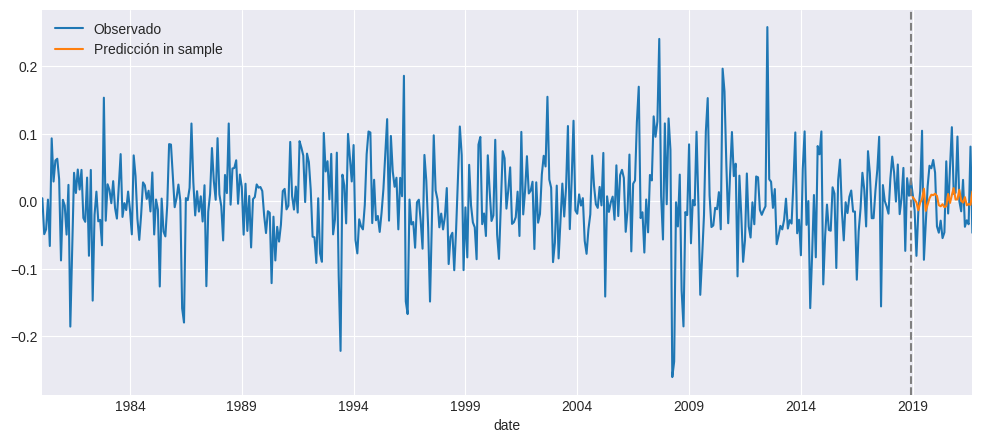

In [ ]:
y.plot(label="Observado")
pred_in.predicted_mean.plot(label="Predicción in sample")
plt.axvline('2018-12', linestyle='--', color='gray')
plt.legend()
plt.show()

La evaluación de las predicciones sobre las mismas observaciones
utilizadas para estimar el modelo puede producir una evaluación
demasiado optimista de su capacidad predictiva.

Para comparar modelos resulta preferible evaluar sus predicciones
sobre observaciones que no hayan sido utilizadas para estimarlos.

Tomamos los datos de `y` hasta diciembre de 2018 y corremos nuestro AR(1)

In [ ]:
y_sub = y.loc[:'2018-12']
ar1_model = ARIMA(y_sub, order=(1,0,0))
ar1_res = ar1_model.fit()
print(ar1_res.summary())

                               SARIMAX Results                                
Dep. Variable:                   dlws   No. Observations:                  467
Model:                 ARIMA(1, 0, 0)   Log Likelihood                 619.128
Date:                Sat, 15 Aug 2026   AIC                          -1232.257
Time:                        16:15:09   BIC                          -1219.818
Sample:                    02-29-1980   HQIC                         -1227.362
                         - 12-31-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0005      0.004      0.149      0.882      -0.007       0.008
ar.L1          0.1753      0.037      4.740      0.000       0.103       0.248
sigma2         0.0041      0.000     20.782      0.0

Imprimimos los estimadores con mayor número de decimales para un análisis más preciso

In [ ]:
for name, val in ar1_res.params.items():
    print(f"{name:10s} = {val:.10f}")

const      = 0.0005388277
ar.L1      = 0.1753215384
sigma2     = 0.0041297162


In [ ]:
mu_hat = ar1_res.params["const"]
rho_hat = ar1_res.params["ar.L1"]

print(f"mu_hat  = {mu_hat:.10f}")
print(f"rho_hat = {rho_hat:.10f}")

mu_hat  = 0.0005388277
rho_hat = 0.1753215384


Definimos el período sobre el cual vamos a evaluar las predicciones.

In [ ]:
start_p = '2019-01'
end_p = '2021-09'

En este caso, la predicción será dinámica.

A partir de enero de 2019 hacemos un pronóstico dinámico:
el primer pronóstico utiliza la última observación disponible,
diciembre de 2018, y los siguientes utilizan los pronósticos anteriores.

In [ ]:
pred_pseudo = ar1_res.get_prediction(
    start=start_p,
    end=end_p,
    dynamic=True
)
pred_pseudo.summary_frame()

dlws,mean,mean_se,mean_ci_lower,mean_ci_upper
2019-01,0.006141,0.064263,-0.119812,0.132093
2019-02,0.001521,0.065243,-0.126353,0.129395
2019-03,0.000711,0.065273,-0.127222,0.128644
2019-04,0.000569,0.065274,-0.127365,0.128503
2019-05,0.000544,0.065274,-0.127390,0.128479
2019-06,0.000540,0.065274,-0.127395,0.128474
2019-07,0.000539,0.065274,-0.127395,0.128473
2019-08,0.000539,0.065274,-0.127396,0.128473
2019-09,0.000539,0.065274,-0.127396,0.128473
2019-10,0.000539,0.065274,-0.127396,0.128473


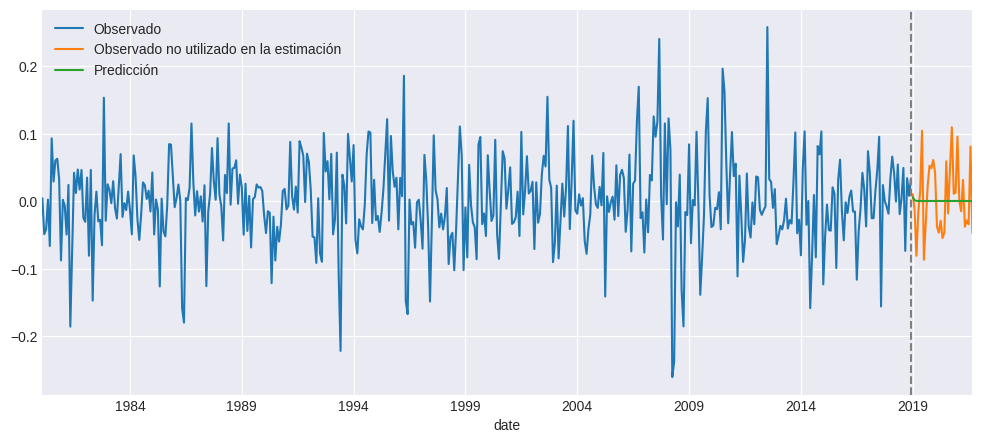

In [ ]:
y_sub.plot(label="Observado")
y.loc[start_p:end_p].plot(label="Observado no utilizado en la estimación")
pred_pseudo.predicted_mean.plot(label="Predicción")
plt.axvline('2018-12', linestyle='--', color='gray')

plt.legend()
plt.show()

Si dentro del `summary_frame` nos interesa observar especialmente los intervalos de confianza:

In [ ]:
pred_pseudo.conf_int()

,lower dlws,upper dlws
2019-01,-0.119812,0.132093
2019-02,-0.126353,0.129395
2019-03,-0.127222,0.128644
2019-04,-0.127365,0.128503
2019-05,-0.127390,0.128479
2019-06,-0.127395,0.128474
2019-07,-0.127395,0.128473
2019-08,-0.127396,0.128473
2019-09,-0.127396,0.128473
2019-10,-0.127396,0.128473


### Predicción "out of Sample" para datos desconocidos.

La última observación disponible es septiembre de 2021.
Pronosticaremos los siguientes 27 períodos, desde octubre de 2021
hasta diciembre de 2023.


Estimo nuevamente el AR(1), pero ahora con todas las observaciones de la muestra, es decir, como comienzo a pronosticar en oct 2021, uso todas las observaciones disponibles hasta septiembre de 2021
para estimar $\mu$ y $\rho$, que serán utilizados para construir los pronósticos.

In [ ]:
y = df["dlws"].dropna()
ar1_model = ARIMA(y, order=(1,0,0))
ar1_res = ar1_model.fit()
print(ar1_res.summary())

                               SARIMAX Results                                
Dep. Variable:                   dlws   No. Observations:                  500
Model:                 ARIMA(1, 0, 0)   Log Likelihood                 668.793
Date:                Sat, 15 Aug 2026   AIC                          -1331.586
Time:                        16:15:10   BIC                          -1318.942
Sample:                    02-29-1980   HQIC                         -1326.625
                         - 09-30-2021                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0009      0.003      0.252      0.801      -0.006       0.008
ar.L1          0.1722      0.036      4.813      0.000       0.102       0.242
sigma2         0.0040      0.000     21.446      0.0

In [ ]:
for name, val in ar1_res.params.items():
    print(f"{name:10s} = {val:.10f}")

const      = 0.0008673574
ar.L1      = 0.1721678135
sigma2     = 0.0040328598


Para pronosticar sobre períodos para los cuales no tenemos
observaciones conocidas, un forecast out-of-sample propiamente dicho,
vamos a utilizar `get_forecast`, indicando el número de períodos
a futuro que queremos pronosticar. En este caso, 27.

El resultado será equivalente al que podríamos obtener al calcularlo con `get_prediction` con los parámetros adecuados.

In [ ]:
pred_out_forecast = ar1_res.get_forecast(steps=27)
df_forecast = pred_out_forecast.summary_frame()
df_forecast

dlws,mean,mean_se,mean_ci_lower,mean_ci_upper
2021-10,-0.007311,0.063505,-0.131779,0.117156
2021-11,-0.000541,0.064439,-0.126839,0.125758
2021-12,0.000625,0.064467,-0.125727,0.126977
2022-01,0.000826,0.064467,-0.125528,0.127179
2022-02,0.000860,0.064467,-0.125494,0.127214
2022-03,0.000866,0.064467,-0.125488,0.127220
2022-04,0.000867,0.064467,-0.125487,0.127221
2022-05,0.000867,0.064467,-0.125487,0.127221
2022-06,0.000867,0.064467,-0.125487,0.127221
2022-07,0.000867,0.064467,-0.125487,0.127221


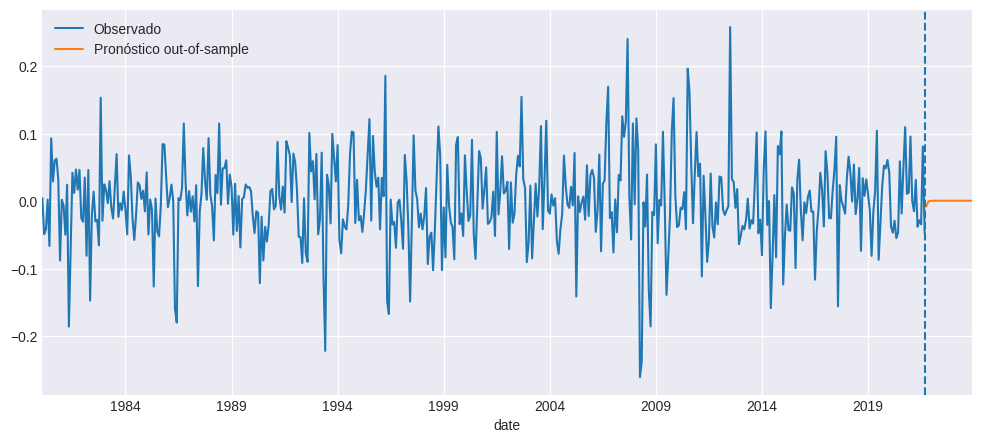

In [ ]:
y.plot(label="Observado")
pred_out_forecast.predicted_mean.plot(label="Pronóstico out-of-sample")
plt.axvline('2021-09', linestyle='--')

plt.legend()
plt.show()

Hacemos foco en un período más acotado del gráfico para mejorar la visualización

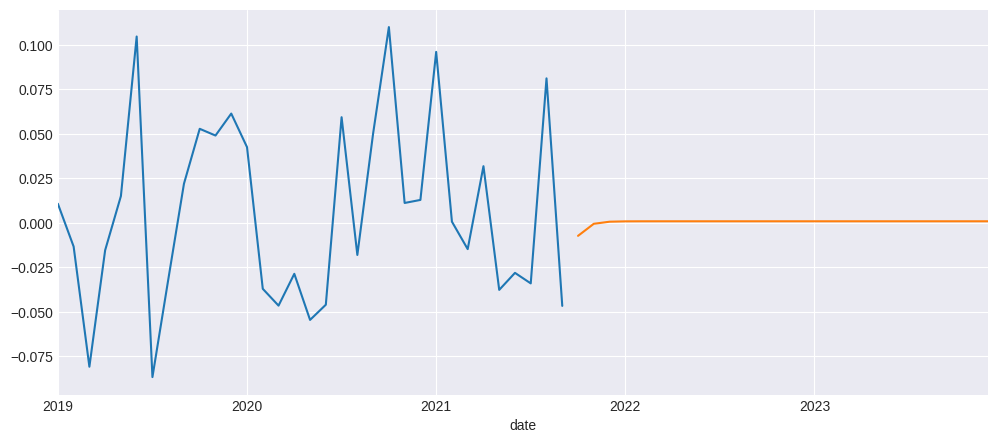

In [ ]:
inicio_grafico = '2019-01'
y.loc[inicio_grafico:].plot()
pred_out_forecast.predicted_mean.plot()
plt.show()

Pronosticar no es lo mismo que evaluar un pronóstico.

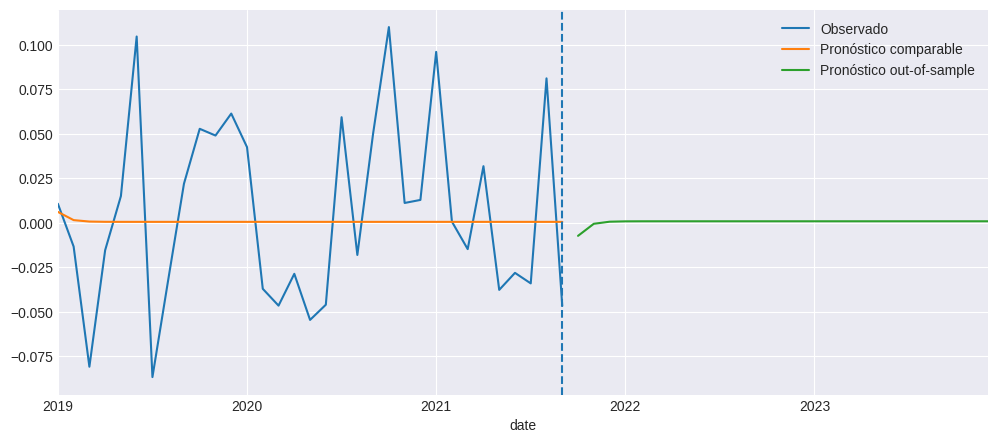

In [ ]:
y.loc['2019-01':].plot(label="Observado")
pred_pseudo.predicted_mean.plot(label="Pronóstico comparable")
pred_out_forecast.predicted_mean.plot(label="Pronóstico out-of-sample")

plt.axvline('2021-09', linestyle='--')
plt.legend()
plt.show()